In [42]:
import sys
import os
import imageio
try:
    from libero.libero import benchmark
    from libero.libero import get_libero_path
    from libero.libero.envs import OffScreenRenderEnv
except ModuleNotFoundError:
    # Append the third_party/libero directory to PYTHONPATH
    libero_path = os.path.join(os.getcwd(), "third_party", "libero")
    if libero_path not in sys.path:
        sys.path.append(libero_path)
    from libero.libero import benchmark
    from libero.libero import get_libero_path
    from libero.libero.envs import OffScreenRenderEnv
    #export PYTHONPATH=$PYTHONPATH:$PWD/third_party/libero
import numpy as np
from openpi_client import image_tools
from openpi_client import websocket_client_policy as _websocket_client_policy
import tqdm
import tyro

LIBERO_DUMMY_ACTION = [0.0] * 6 + [-1.0]
LIBERO_ENV_RESOLUTION = 256  # resolution used to render training data


In [71]:
benchmark_dict['libero_10']().tasks[3]

[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


Task(name='KITCHEN_SCENE4_put_the_black_bowl_in_the_bottom_drawer_of_the_cabinet_and_close_it', language='put the black bowl in the bottom drawer of the cabinet and close it', problem='Libero', problem_folder='libero_10', bddl_file='KITCHEN_SCENE4_put_the_black_bowl_in_the_bottom_drawer_of_the_cabinet_and_close_it.bddl', init_states_file='KITCHEN_SCENE4_put_the_black_bowl_in_the_bottom_drawer_of_the_cabinet_and_close_it.pruned_init')

In [58]:
@benchmark.register_benchmark
class LIBERO_10_B(benchmark.Benchmark):
    def __init__(self, task_order_index=0):
        super().__init__(task_order_index=task_order_index)
        self.name = "libero_10_b"
        self._make_benchmark()

In [45]:
benchmark.print_benchmark()


{'libero_spatial': <class 'libero.libero.benchmark.LIBERO_SPATIAL'>, 'libero_object': <class 'libero.libero.benchmark.LIBERO_OBJECT'>, 'libero_goal': <class 'libero.libero.benchmark.LIBERO_GOAL'>, 'libero_90': <class 'libero.libero.benchmark.LIBERO_90'>, 'libero_10': <class 'libero.libero.benchmark.LIBERO_10'>, 'libero_100': <class 'libero.libero.benchmark.LIBERO_100'>, 'libero_100_b': <class '__main__.LIBERO_100_B'>}


In [59]:
mycls = benchmark.get_benchmark('libero_10_b')

In [60]:
task_maps = benchmark.task_maps



task_maps['libero_10_b'] = task_maps['libero_10']
a = mycls()

[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [6]:
from libero.libero import benchmark
from libero.libero.envs import OffScreenRenderEnv


benchmark_dict = benchmark.get_benchmark_dict()
task_suite_name = "libero_10" # can also choose libero_spatial, libero_object, etc.
task_suite = benchmark_dict[task_suite_name]()

# retrieve a specific task
task_id = 0
task = task_suite.get_task(task_id)
task_name = task.name
task_description = task.language
task_bddl_file = os.path.join(get_libero_path("bddl_files"), task.problem_folder, task.bddl_file)
print(f"[info] retrieving task {task_id} from suite {task_suite_name}, the " + \
      f"language instruction is {task_description}, and the bddl file is {task_bddl_file}")

# step over the environment
env_args = {
    "bddl_file_name": task_bddl_file,
    "camera_heights": 128,
    "camera_widths": 128
}
env = OffScreenRenderEnv(**env_args)
env.seed(0)
env.reset()
init_states = task_suite.get_task_init_states(task_id) # for benchmarking purpose, we fix the a set of initial states
init_state_id = 0
env.set_init_state(init_states[init_state_id])


[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[Warning]: datasets path /home/christopher/Documents/openpi/third_party/libero/libero/libero/../datasets does not exist!
[info] retrieving task 0 from suite libero_10, the language instruction is put both the alphabet soup and the tomato sauce in the basket, and the bddl file is /home/christopher/Documents/openpi/third_party/libero/libero/libero/./bddl_files/libero_10/LIVING_ROOM_SCENE2_put_both_the_alphabet_soup_and_the_tomato_sauce_in_the_basket.bddl
[Warning]: datasets path /home/christopher/Documents/openpi/third_party/libero/libero/libero/../datasets does not exist!


OrderedDict([('robot0_joint_pos',
              array([-0.01988284, -0.18734066,  0.0076694 , -2.4034026 ,  0.00496468,
                      2.2453365 ,  0.7948479 ])),
             ('robot0_joint_pos_cos',
              array([ 0.99980234,  0.982503  ,  0.99997059, -0.73968777,  0.99998768,
                     -0.62453826,  0.70039334])),
             ('robot0_joint_pos_sin',
              array([-0.01988153, -0.18624675,  0.00766933, -0.67295022,  0.00496466,
                      0.78099421,  0.71375708])),
             ('robot0_joint_vel', array([0., 0., 0., 0., 0., 0., 0.])),
             ('robot0_eef_pos',
              array([-0.03749909, -0.00537552,  0.71296794])),
             ('robot0_eef_quat',
              array([ 0.99981815, -0.01216225,  0.0146372 , -0.00122224])),
             ('robot0_gripper_qpos', array([ 0.020833, -0.020833])),
             ('robot0_gripper_qvel', array([0., 0.])),
             ('agentview_image',
              array([[[ 81,  57,  45],
          

In [12]:
from libero.libero.envs.predicates import get_predicate_fn_dict, get_predicate_fn, eval_predicate_fn
predicate_dict = get_predicate_fn_dict()
for k, v in predicate_dict.items():
    print(f"{k}: {v}")


true: <libero.libero.envs.predicates.base_predicates.TruePredicateFn object at 0x78c38d748a60>
false: <libero.libero.envs.predicates.base_predicates.FalsePredicateFn object at 0x78c38d748a90>
in: <libero.libero.envs.predicates.base_predicates.In object at 0x78c38d748ac0>
on: <libero.libero.envs.predicates.base_predicates.On object at 0x78c38d748b20>
up: <libero.libero.envs.predicates.base_predicates.Up object at 0x78c38d748af0>
printjointstate: <libero.libero.envs.predicates.base_predicates.PrintJointState object at 0x78c38d748dc0>
open: <libero.libero.envs.predicates.base_predicates.Open object at 0x78c38d748eb0>
close: <libero.libero.envs.predicates.base_predicates.Close object at 0x78c38d748fa0>
turnon: <libero.libero.envs.predicates.base_predicates.TurnOn object at 0x78c38d7500d0>
turnoff: <libero.libero.envs.predicates.base_predicates.TurnOff object at 0x78c38d7501f0>
True


In [17]:
print(globals().keys())

dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', 'open', '_', '__', '___', '__vsc_ipynb_file__', '_i', '_ii', '_iii', '_i1', 'imageio', '_i2', '_i3', 'sys', 'os', 'libero_path', 'benchmark', 'get_libero_path', 'OffScreenRenderEnv', 'np', 'image_tools', '_websocket_client_policy', 'tqdm', 'tyro', 'LIBERO_DUMMY_ACTION', 'LIBERO_ENV_RESOLUTION', '_i4', 'benchmark_dict', 'task_suite_name', 'task_suite', 'task_id', 'task', 'task_name', 'task_description', 'task_bddl_file', 'env_args', 'env', 'init_states', 'init_state_id', 'dummy_action', 'step', 'obs', 'reward', 'done', 'info', '_i5', '_i6', '_6', '_i7', '_i8', '_i9', 'get_predicate_fn_dict', 'get_predicate_fn', 'predicate_dict', '_i10', 'k', 'v', '_i11', 'eval_predicate_fn', '_i12', 'name', '_i13', '_i14', '_i15', '_i16', '_i17'])


In [24]:

print(type(env.env))
# print(isinstance(env.env, BDDLBaseDomain))

<class 'libero.libero.envs.problems.libero_living_room_tabletop_manipulation.Libero_Living_Room_Tabletop_Manipulation'>


In [41]:
print(obs.keys())

odict_keys(['robot0_joint_pos', 'robot0_joint_pos_cos', 'robot0_joint_pos_sin', 'robot0_joint_vel', 'robot0_eef_pos', 'robot0_eef_quat', 'robot0_gripper_qpos', 'robot0_gripper_qvel', 'agentview_image', 'robot0_eye_in_hand_image', 'alphabet_soup_1_pos', 'alphabet_soup_1_quat', 'alphabet_soup_1_to_robot0_eef_pos', 'alphabet_soup_1_to_robot0_eef_quat', 'cream_cheese_1_pos', 'cream_cheese_1_quat', 'cream_cheese_1_to_robot0_eef_pos', 'cream_cheese_1_to_robot0_eef_quat', 'tomato_sauce_1_pos', 'tomato_sauce_1_quat', 'tomato_sauce_1_to_robot0_eef_pos', 'tomato_sauce_1_to_robot0_eef_quat', 'ketchup_1_pos', 'ketchup_1_quat', 'ketchup_1_to_robot0_eef_pos', 'ketchup_1_to_robot0_eef_quat', 'orange_juice_1_pos', 'orange_juice_1_quat', 'orange_juice_1_to_robot0_eef_pos', 'orange_juice_1_to_robot0_eef_quat', 'milk_1_pos', 'milk_1_quat', 'milk_1_to_robot0_eef_pos', 'milk_1_to_robot0_eef_quat', 'butter_1_pos', 'butter_1_quat', 'butter_1_to_robot0_eef_pos', 'butter_1_to_robot0_eef_quat', 'basket_1_pos', 

In [74]:
from PIL import Image
from IPython.display import display




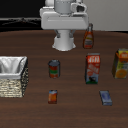

In [76]:
img = obs['agentview_image']
img = np.ascontiguousarray(obs["agentview_image"][::-1, ::-1])
# Convert NumPy array to PIL image
pil_img = Image.fromarray(img.astype('uint8'))

# Display the image
display(pil_img)


In [33]:
for e in env.env.object_states_dict.keys():
    print(e)

alphabet_soup_1
cream_cheese_1
tomato_sauce_1
ketchup_1
orange_juice_1
milk_1
butter_1
basket_1
living_room_table_basket_init_region
living_room_table_milk_init_region
living_room_table_cream_cheese_init_region
living_room_table_orange_juice_init_region
living_room_table_tomato_sauce_init_region
living_room_table_alphabet_soup_init_region
living_room_table_butter_init_region
living_room_table_ketchup_init_region
basket_1_contain_region


In [ ]:
print(env.env._check_predicate('on'))

In [82]:
print(type(env.env))

<class 'libero.libero.envs.problems.libero_living_room_tabletop_manipulation.Libero_Living_Room_Tabletop_Manipulation'>


In [81]:
name = 'on'
print(env.env._eval_predicate((name, 'milk_1', 'living_room_table_basket_init_region')))

False


In [80]:
env.env.object_states_dict['milk_1']

In [8]:

dummy_action = [0.] * 7
for step in range(1):
    obs, reward, done, info = env.step(dummy_action)
    print(info)
print(env.__attributes__)

{}


AttributeError: 'OffScreenRenderEnv' object has no attribute '__attributes__'

In [ ]:
#env.close()